First 5 rows of full data:
Price            Close                                High              \
Ticker            AAPL        MSFT        TSLA        AAPL        MSFT   
Date                                                                     
2023-01-03  123.096016  233.452805  108.099998  128.833995  239.465007   
2023-01-04  124.365662  223.240829  113.639999  126.629364  226.914402   
2023-01-05  123.046806  216.624496  110.339996  125.753403  221.730491   
2023-01-06  127.574211  219.177460  113.059998  128.233635  219.986234   
2023-01-09  128.095856  221.311462  119.769997  131.304413  225.326105   

Price                          Low                                Open  \
Ticker            TSLA        AAPL        MSFT        TSLA        AAPL   
Date                                                                     
2023-01-03  118.800003  122.210219  231.328550  104.639999  128.223785   
2023-01-04  114.589996  123.105865  220.181135  107.519997  124.887295   
2023-01-05

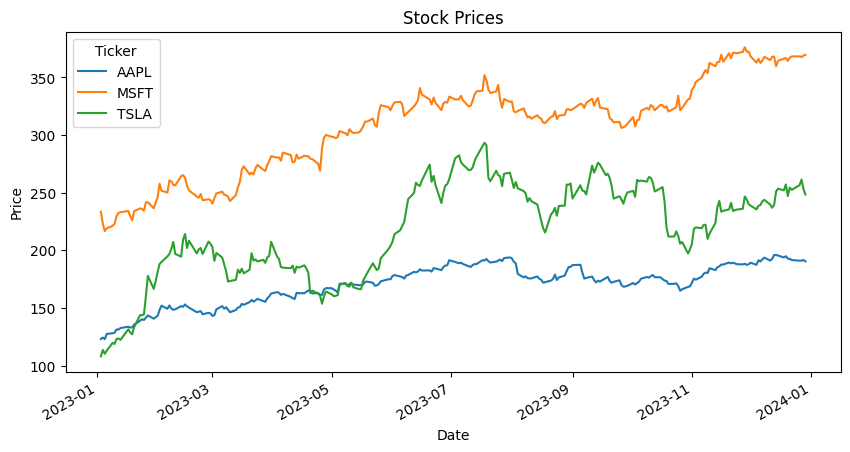

Daily returns:
Ticker          AAPL      MSFT      TSLA
Date                                    
2023-01-03       NaN       NaN       NaN
2023-01-04  0.010314 -0.043743  0.051249
2023-01-05 -0.010605 -0.029638 -0.029039
2023-01-06  0.036794  0.011785  0.024651
2023-01-09  0.004089  0.009736  0.059349
Average daily returns:
Ticker
AAPL    0.001835
MSFT    0.001972
TSLA    0.003893
dtype: float64
Risk (standard deviation):
Ticker
AAPL    0.012570
MSFT    0.015824
TSLA    0.033166
dtype: float64
Annual Sharpe Ratio:
Ticker
AAPL    2.116843
MSFT    1.818678
TSLA    1.787252
dtype: float64
Summary table:
        Mean Return      Risk  Annual Sharpe
Ticker                                      
AAPL       0.001835  0.012570       2.116843
MSFT       0.001972  0.015824       1.818678
TSLA       0.003893  0.033166       1.787252


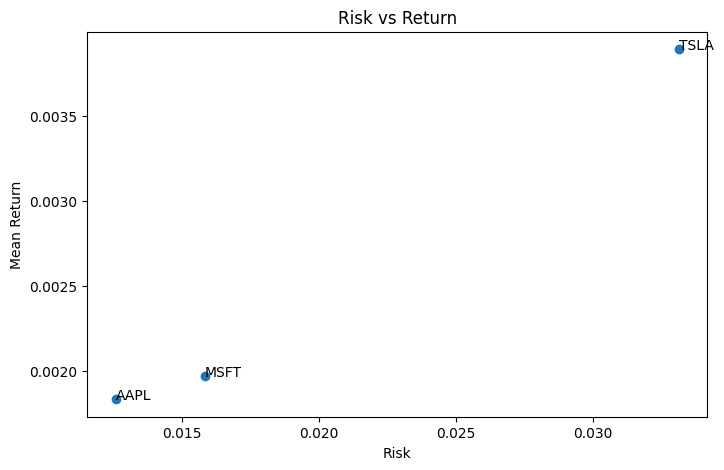

Normalized prices:
Ticker          AAPL      MSFT      TSLA
Date                                    
2023-01-03  1.000000  1.000000  1.000000
2023-01-04  1.010314  0.956257  1.051249
2023-01-05  0.999600  0.927916  1.020722
2023-01-06  1.036380  0.938851  1.045883
2023-01-09  1.040617  0.947992  1.107956
Files saved successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Select the stocks used in the project
stocks = ["AAPL", "TSLA", "MSFT"]

# Download stock data for 2023
df = yf.download(
    stocks,
    start="2023-01-01",
    end="2024-01-01",
    auto_adjust=True,
    progress=False
)

# Display the first 5 rows of the full data
print("First 5 rows of full data:")
print(df.head())

# Extract closing prices
prices = df["Close"]

# Display closing prices and data information
print("Closing prices:")
print(prices.head())

print("Shape of prices data:")
print(prices.shape)

print("Column names:")
print(prices.columns)

# Plot stock prices
prices.plot(figsize=(10, 5))
plt.title("Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# Calculate daily returns
ret = prices.pct_change()

print("Daily returns:")
print(ret.head())

print("Average daily returns:")
print(ret.mean())

print("Risk (standard deviation):")
print(ret.std())

# Annual Sharpe calculation
rf = 0.04 / 252
daily_sharpe = (ret.mean() - rf) / ret.std()
annual_sharpe = daily_sharpe * (252 ** 0.5)

print("Annual Sharpe Ratio:")
print(annual_sharpe)

# Create summary table
summary = pd.DataFrame({
    "Mean Return": ret.mean(),
    "Risk": ret.std(),
    "Annual Sharpe": annual_sharpe
})

print("Summary table:")
print(summary)

# Plot risk vs return
plt.figure(figsize=(8, 5))
plt.scatter(summary["Risk"], summary["Mean Return"])

for stock in summary.index:
    plt.text(summary.loc[stock, "Risk"], summary.loc[stock, "Mean Return"], stock)

plt.title("Risk vs Return")
plt.xlabel("Risk")
plt.ylabel("Mean Return")
plt.show()

# Normalize prices
norm_price = prices / prices.iloc[0]

print("Normalized prices:")
print(norm_price.head())

# Save files for dashboard use
price_reset = prices.reset_index()
price_reset.to_csv("prices.csv", index=False)

norm_price_reset = norm_price.reset_index()
norm_price_reset.to_csv("normalized_price.csv", index=False)

summary_reset = summary.reset_index()
summary_reset.to_csv("summary.csv", index=False)

print("Files saved successfully")


from google.colab import files

files.download("prices.csv")
files.download("normalized_price.csv")
files.download("summary.csv")

